# Domain-Adversarial SSL: the H4 Strengthening Attempt


The ablation notebook traced that regression specifically to the framework's *fixed-bandwidth spatial-distance* weighting term, which collapses toward uninformative near-zero weights once every labelled point is far from the unlabelled centroid -- not to adding spatial awareness per se. This notebook tests whether replacing that fixed heuristic with a *learned* covariate-shift correction actually strengthens H4, per your instruction to attempt strengthening before considering a reframe.

**The new model** (`ssl_spatial.models.neural_distribution_aware.fit_domain_adversarial_ssl`): a shared MLP trunk feeding a label-prediction head and a domain-classification head, the latter behind a gradient-reversal layer (DANN; Ganin et al., 2016, already cited in the manuscript's Related Work), so the trunk is trained adversarially to make labelled/unlabelled features indistinguishable to a discriminator that adapts to the actual data at hand -- combined with Mean-Teacher-style consistency regularisation (reusing `neural_ssl.py`'s ramp-up schedule and EMA update) on the unlabelled pool. Evaluated at 20 seeds across all five datasets (`configs/neural_da_ssl_v2.yaml`), alongside plain self-training, re-weighting alone, and the existing full framework, via `ssl_spatial.experiments.neural_da_ssl_v2` (a thin wrapper reusing `spatial_methods_comparison.py`'s sweep machinery unchanged).

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT / "src"))

import numpy as np
import pandas as pd

from ssl_spatial.metrics.bootstrap import bootstrap_ci_drop
from ssl_spatial.plotting import METHOD_COLORS, METHOD_LABELS, new_figure, savefig

FIG_DIR = REPO_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

METHOD_ORDER = ["self_training", "reweighted_self_training", "full_distribution_aware", "domain_adversarial_ssl"]
DATASET_ORDER = ["synthetic", "wilds", "housing", "socioeconomic", "air_quality"]
DATASET_LABELS = {"synthetic": "Synthetic", "wilds": "PovertyMap-WILDS", "housing": "Housing",
                   "socioeconomic": "Socio-economic", "air_quality": "Air quality"}

print("Repo root:", REPO_ROOT)

Repo root: /mnt/c/Users/Lenovo/Desktop/SSL


## 1. Load the sweep

`configs/neural_da_ssl_v2.yaml`: 6 mismatch-severity levels × 20 seeds × 4 methods × 5 datasets = 2,400 runs.

In [2]:
df = pd.read_csv(REPO_ROOT / "results" / "neural_da_ssl_v2.csv")
print(f"{len(df)} rows: {df['dataset'].nunique()} datasets × {df['mismatch_alpha'].nunique()} alphas × "
      f"{df['seed'].nunique()} seeds × {df['method'].nunique()} methods")
df.groupby(["dataset", "method"]).size().unstack()

2400 rows: 5 datasets × 6 alphas × 20 seeds × 4 methods


method,domain_adversarial_ssl,full_distribution_aware,reweighted_self_training,self_training
dataset,,,,
air_quality,120,120,120,120
housing,120,120,120,120
socioeconomic,120,120,120,120
synthetic,120,120,120,120
wilds,120,120,120,120


## 2. Accuracy drop, with bootstrap confidence intervals

In [3]:
drop = bootstrap_ci_drop(df, group_cols=["dataset", "method"], value_col="accuracy_out_region",
                          alpha_col="mismatch_alpha", lo=0.0, hi=1.0, n_boot=200, seed=0)
drop["drop_pp"] = drop["drop"] * 100
drop["ci_low_pp"] = drop["ci_low"] * 100
drop["ci_high_pp"] = drop["ci_high"] * 100
drop["method"] = pd.Categorical(drop["method"], categories=METHOD_ORDER, ordered=True)
drop["dataset"] = pd.Categorical(drop["dataset"], categories=DATASET_ORDER, ordered=True)
drop = drop.sort_values(["dataset", "method"])

table = drop.copy()
table["method"] = table["method"].map(METHOD_LABELS)
table["dataset"] = table["dataset"].map(DATASET_LABELS)
table["drop (95% CI)"] = table.apply(
    lambda r: f"{r['drop_pp']:.2f} [{r['ci_low_pp']:.2f}, {r['ci_high_pp']:.2f}]", axis=1)
table[["dataset", "method", "drop (95% CI)"]].reset_index(drop=True)

,dataset,method,drop (95% CI)
0,Synthetic,Self-training,"2.42 [0.43, 4.82]"
1,Synthetic,Reweighted self-training,"3.33 [1.18, 6.17]"
2,Synthetic,Full framework (all three),"8.92 [4.66, 13.19]"
3,Synthetic,Domain-adversarial SSL,"2.58 [-0.25, 5.14]"
4,PovertyMap-WILDS,Self-training,"14.57 [9.72, 21.40]"
5,PovertyMap-WILDS,Reweighted self-training,"12.00 [5.70, 18.74]"
6,PovertyMap-WILDS,Full framework (all three),"21.30 [15.89, 27.17]"
7,PovertyMap-WILDS,Domain-adversarial SSL,"3.80 [0.30, 7.03]"
8,Housing,Self-training,"13.75 [12.25, 15.23]"
9,Housing,Reweighted self-training,"12.22 [10.55, 13.55]"


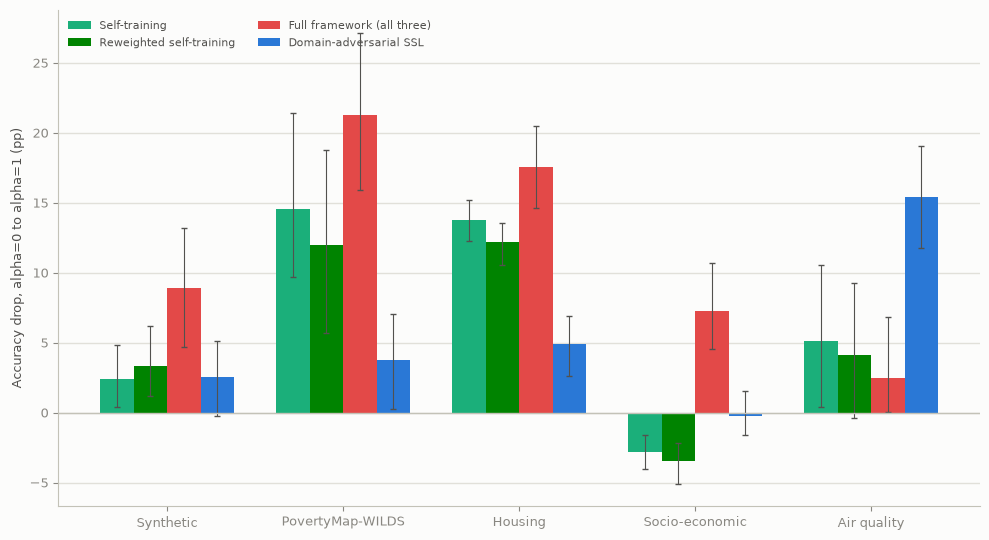

In [4]:
fig, ax = new_figure(figsize=(10, 5.5))
x = np.arange(len(DATASET_ORDER))
width = 0.19
for i, method in enumerate(METHOD_ORDER):
    sub = drop[drop["method"] == method].set_index("dataset").loc[DATASET_ORDER]
    offset = (i - (len(METHOD_ORDER) - 1) / 2) * width
    ax.bar(x + offset, sub["drop_pp"], width, color=METHOD_COLORS[method], label=METHOD_LABELS[method],
           yerr=[sub["drop_pp"] - sub["ci_low_pp"], sub["ci_high_pp"] - sub["drop_pp"]],
           capsize=2, error_kw={"linewidth": 0.8, "ecolor": "#52514e"})
ax.axhline(0, color="#c3c2b7", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASET_ORDER], fontsize=9)
ax.set_ylabel("Accuracy drop, alpha=0 to alpha=1 (pp)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=8, labelcolor="#52514e", ncol=2, loc="upper left")
savefig(fig, FIG_DIR / "fig17_neural_da_ssl_v2.png")

## 3. Is the improvement real, or just a lower starting point?

A smaller drop can be a cheap win if a method is simply worse everywhere (nothing left to lose). Checked directly: raw out-of-region accuracy at both severity extremes, and out-of-region expected calibration error, averaged across all five datasets.

In [5]:
acc = df.groupby(["method", "mismatch_alpha"])["accuracy_out_region"].mean().unstack()
ece = df.groupby(["method", "mismatch_alpha"])["ece_out_region"].mean().unstack()
summary = pd.DataFrame({
    "accuracy (alpha=0)": acc.loc[METHOD_ORDER, 0.0],
    "accuracy (alpha=1)": acc.loc[METHOD_ORDER, 1.0],
    "ECE out-of-region (alpha=0)": ece.loc[METHOD_ORDER, 0.0],
    "ECE out-of-region (alpha=1)": ece.loc[METHOD_ORDER, 1.0],
}).round(3)
summary.index = [METHOD_LABELS[m] for m in summary.index]
summary

,accuracy (alpha=0),accuracy (alpha=1),ECE out-of-region (alpha=0),ECE out-of-region (alpha=1)
Self-training,0.690,0.624,0.220,0.326
Reweighted self-training,0.681,0.625,0.222,0.326
Full framework (all three),0.662,0.547,0.219,0.369
Domain-adversarial SSL,0.719,0.666,0.228,0.293
